# 🏥 Análise das Unidades Básicas de Saúde (UBS) no Brasil

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [10]:
# Carregar os dados com encoding correto para caracteres brasileiros
df = pd.read_csv('Unidades_Basicas_Saude-UBS.csv', sep=';', encoding='latin1')

# Limpeza: remover aspas e converter para numérico
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = df[col].astype(str).str.replace('"', '').str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head(3)

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,-43.991409
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,-35.599539
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,-35.229436


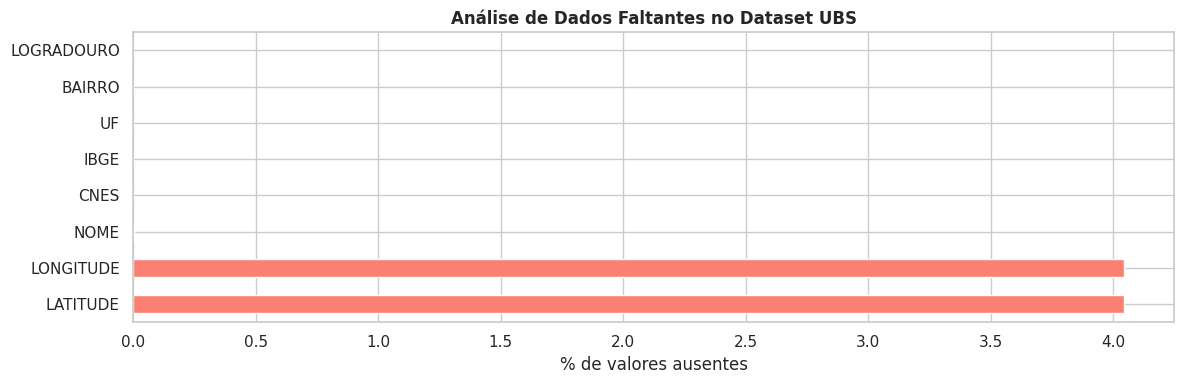


Total de registros: 47,673


In [11]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_all = missing[missing >= 0]

fig, ax = plt.subplots(figsize=(12, 4))
missing_all.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Análise de Dados Faltantes no Dataset UBS', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTotal de registros: {len(df):,}')

## Análise Exploratória de Dados

### 📍 Distribuição por Estado (UF)

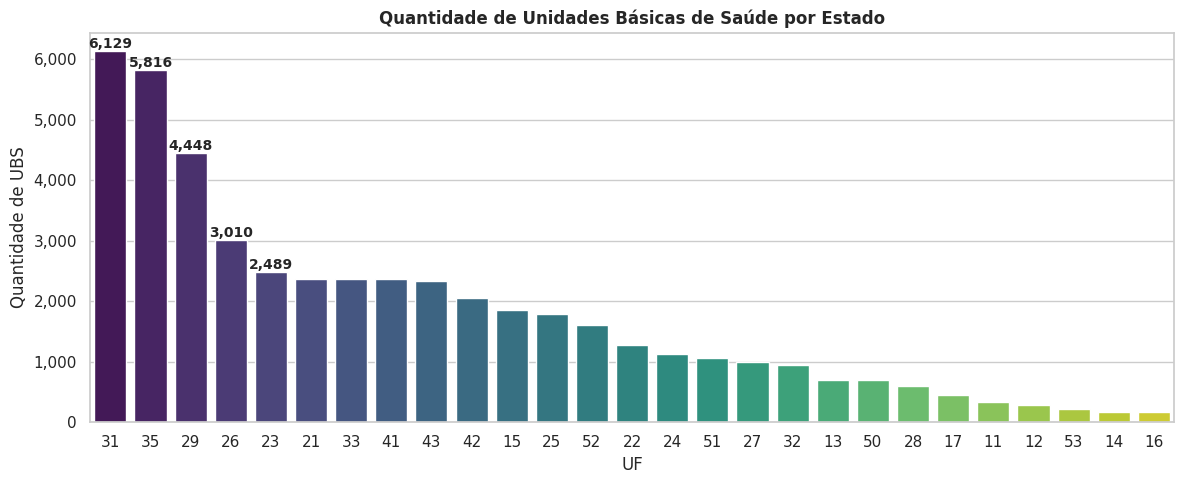

In [12]:
por_uf = df['UF'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=por_uf.index.astype(str), y=por_uf.values, palette='viridis', ax=ax)
ax.set_xlabel('UF')
ax.set_ylabel('Quantidade de UBS')
ax.set_title('Quantidade de Unidades Básicas de Saúde por Estado', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, v in enumerate(por_uf.head(5)):
    ax.text(i, v + 50, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 🏙️ Top 15 Municípios com Mais UBS

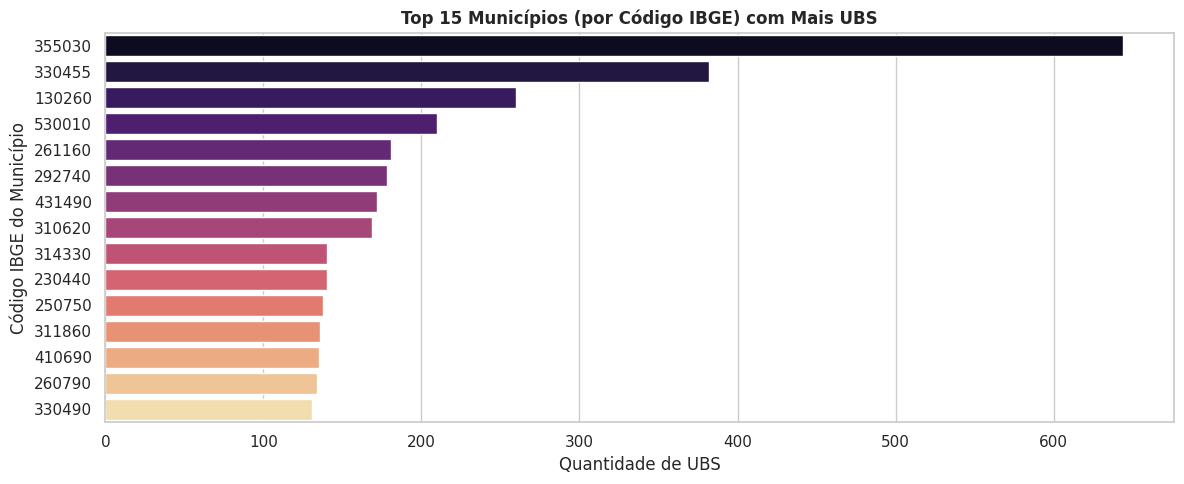

In [13]:
top_ibge = df['IBGE'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_ibge.values, y=top_ibge.index.astype(str), palette='magma', ax=ax)
ax.set_xlabel('Quantidade de UBS')
ax.set_ylabel('Código IBGE do Município')
ax.set_title('Top 15 Municípios (por Código IBGE) com Mais UBS', fontweight='bold')
plt.tight_layout()
plt.show()

### 🗺️ Distribuição Geoespacial das UBS

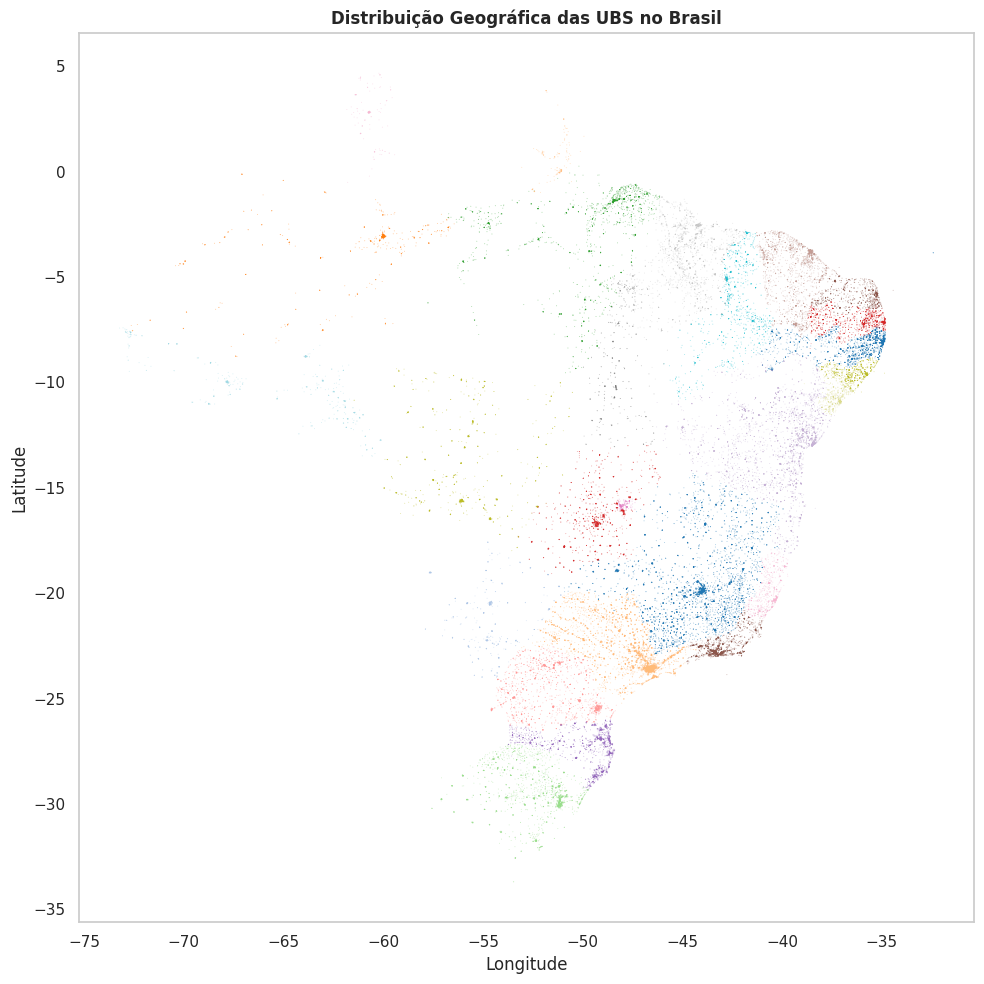

Exibindo 45,743/47,673 unidades com coordenadas válidas.


In [14]:
df_geo = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'UF'])
lat = df_geo['LATITUDE'].astype(float).values
lon = df_geo['LONGITUDE'].astype(float).values
colors, _ = pd.factorize(df_geo['UF'])

plt.figure(figsize=(10, 10))
plt.scatter(lon, lat, c=colors, cmap='tab20', alpha=0.4, s=0.5, edgecolors='none')

plt.title('Distribuição Geográfica das UBS no Brasil', fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.tight_layout()
plt.show()

print(f'Exibindo {len(df_geo):,}/{len(df):,} unidades com coordenadas válidas.')

### 🏠 Bairros com maior número de UBS

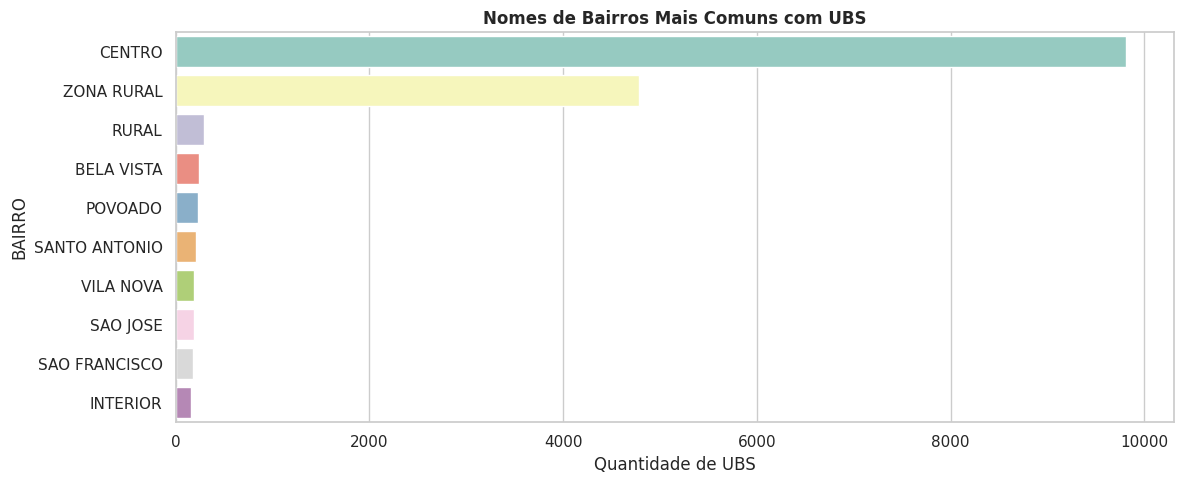

In [15]:
top_bairros = df['BAIRRO'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_bairros.values, y=top_bairros.index.astype(str), palette='Set3', ax=ax)
ax.set_xlabel('Quantidade de UBS')
ax.set_title('Nomes de Bairros Mais Comuns com UBS', fontweight='bold')
plt.tight_layout()
plt.show()